In [1]:
import os
import sys
sys.path.append(r'../')
import numpy as np
import matplotlib.pyplot as plt
import scipy.io as sio
import pandas as pd

from src.d_CSL import GcStar
from src.d_CSL import Visualize_on_topography
from src.dataload import *
from src.dataPreProcessing import replace_nan


# Remove null values df. dropna(inplace=True)

# if variables are changed on the fly 
from reloading import reloading
from tqdm.notebook import tqdm

In [2]:
%reload_ext autoreload
%autoreload 2
from src.d_CSL import *

In [3]:
N_PASTS, n_lags, n_perm = list(range(2, 4)), 1, 1000

In [4]:
def make_GT(name):
    start = name.find('.')
    gt_name = name[:start] + '_gt_processed.csv'
    dat = load_data(name)
    data = dat['ts'].T
    n = data.shape[0]

    df = pd.read_csv(gt_name, header=None)
    gt = df.values
    GT = np.zeros((n,n))
    for r in gt:
        GT[r[0], r[1]] = 1
    return GT.T

def mat_func(A, inf):
    return (40 * np.logical_and(A != 0, inf != 0) +
                30 * np.logical_and(A == 0, inf != 0) +
                20 * np.logical_and(A != 0, inf == 0) +
                10 * np.logical_and(A == 0, inf == 0))

names[0][:names[0].find('.')].replace('timeseries', '')

In [5]:
%%time

# load data
os.chdir(r'./data/fMRI_sims/')
names = [n for n in os.listdir() if n.endswith('.mat')]
INFs = {}
CONF_MTX = {}
for i in range(len(names)):
    
    A = make_GT(names[i])
    X_ = load_data(names[i])
    X = X_['ts'].T
    
    print('Data ' + names[i] + ' with len = {}'.format(X.shape[1]))
    print('')
    
    # Analysis
    infs = []
    conf_mtx = []
    for a, n in enumerate(N_PASTS):
        
        print(f'{n} pasts')
        gcstar = GcStar(n_perm = 1000, 
                    n_pasts = n, 
                    n_lags = n_lags,
                    temporal = True,
                    method = ' ')
    
        gcstar.fit(X, verbose = 0)
        inf = gcstar.get_connectivity_matrix(alpha=0, beta=0, simulation=False)   # 
        infs.append(inf)
        conf = gcstar.compute_confusion_matrix(A)
        conf_mtx.append(conf)
        
    INFs[names[i]] = infs
    CONF_MTX[names[i]] = conf_mtx
    print('')
    print('')

Data sim1.mat with len = 10000

2 pasts
3 pasts


Data sim10.mat with len = 10000

2 pasts
3 pasts


Data sim11.mat with len = 10000

2 pasts
3 pasts


Data sim12.mat with len = 10000

2 pasts
3 pasts


Data sim13.mat with len = 10000

2 pasts
3 pasts


Data sim14.mat with len = 10000

2 pasts
3 pasts


Data sim15.mat with len = 10000

2 pasts
3 pasts


Data sim16.mat with len = 10000

2 pasts
3 pasts


Data sim17.mat with len = 10000

2 pasts
3 pasts


Data sim18.mat with len = 10000

2 pasts
3 pasts


Data sim19.mat with len = 120000

2 pasts
3 pasts


Data sim2.mat with len = 10000

2 pasts
3 pasts


Data sim20.mat with len = 120000

2 pasts
3 pasts


Data sim21.mat with len = 10000

2 pasts
3 pasts


Data sim22.mat with len = 10000

2 pasts
3 pasts


Data sim23.mat with len = 10000

2 pasts
3 pasts


Data sim24.mat with len = 10000

2 pasts
3 pasts


Data sim25.mat with len = 5000

2 pasts
3 pasts


Data sim26.mat with len = 2500

2 pasts
3 pasts


Data sim27.mat with len = 2500

2

In [6]:
def confusion_matrix(inferred, A):
    TP_inf = np.sum(np.logical_and(A != 0,inferred!=0))
    FN_inf = np.sum(np.logical_and(A != 0,inferred==0))
    FP_inf = np.sum(np.logical_and(A == 0,inferred!=0))
    TN_inf = np.sum(np.logical_and(A == 0,inferred==0))
    return np.array([[TP_inf,FP_inf],
                     [FN_inf,TN_inf]])


def apr_metrics(confusion_matrix):
    confusion_matrix = confusion_matrix.flatten()
    accuracy = (confusion_matrix[0] + confusion_matrix[3])/(np.sum(confusion_matrix))
    precision = confusion_matrix[0]/(confusion_matrix[0]+confusion_matrix[1])
    recall = confusion_matrix[0]/(confusion_matrix[0]+confusion_matrix[2])
    FPR = confusion_matrix[1]/(confusion_matrix[1]+confusion_matrix[3])
    return np.array([accuracy, precision, recall, FPR])

In [7]:
METRICs = {}
for keys in CONF_MTX:
    metrics = []
    for j in range(2):
        metrics.append(apr_metrics(CONF_MTX[keys][j]))        
    METRICs[keys] = metrics

In [8]:
METRICs

{'sim1.mat': [array([0.72      , 0.58823529, 1.        , 0.46666667]),
  array([0.72      , 0.58823529, 1.        , 0.46666667])],
 'sim10.mat': [array([0.44      , 0.41666667, 1.        , 0.93333333]),
  array([0.4, 0.4, 1. , 1. ])],
 'sim11.mat': [array([0.54      , 0.31343284, 1.        , 0.58227848]),
  array([0.54      , 0.31343284, 1.        , 0.58227848])],
 'sim12.mat': [array([0.78      , 0.48837209, 1.        , 0.27848101]),
  array([0.82      , 0.53846154, 1.        , 0.2278481 ])],
 'sim13.mat': [array([0.76      , 0.68421053, 1.        , 0.5       ]),
  array([0.76      , 0.68421053, 1.        , 0.5       ])],
 'sim14.mat': [array([0.6       , 0.5       , 1.        , 0.66666667]),
  array([0.76 , 0.625, 1.   , 0.4  ])],
 'sim15.mat': [array([0.48      , 0.43478261, 1.        , 0.86666667]),
  array([0.48      , 0.43478261, 1.        , 0.86666667])],
 'sim16.mat': [array([0.52      , 0.5       , 1.        , 0.92307692]),
  array([0.56      , 0.52173913, 1.        , 0.846153

C:\Users\sadiq\AppData\Local\Temp\ipykernel_22232\3975460828.py:3: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig,ax = plt.subplots(1,2,figsize=(10,4))


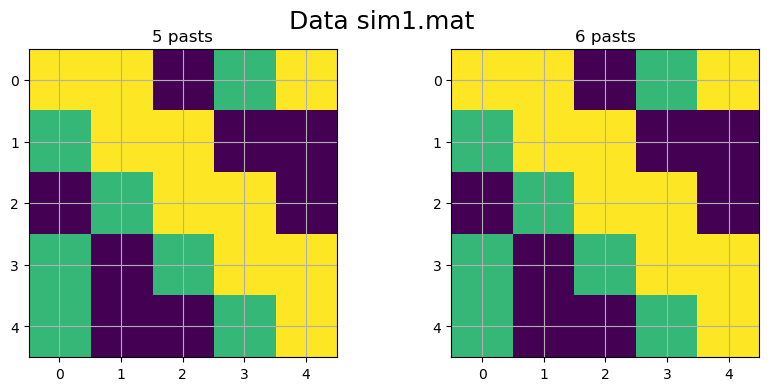

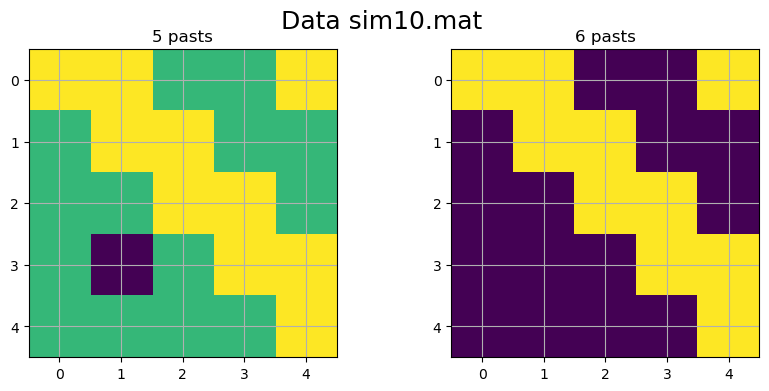

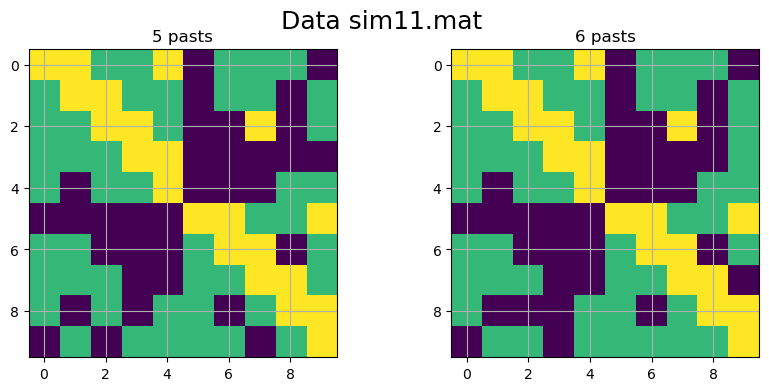

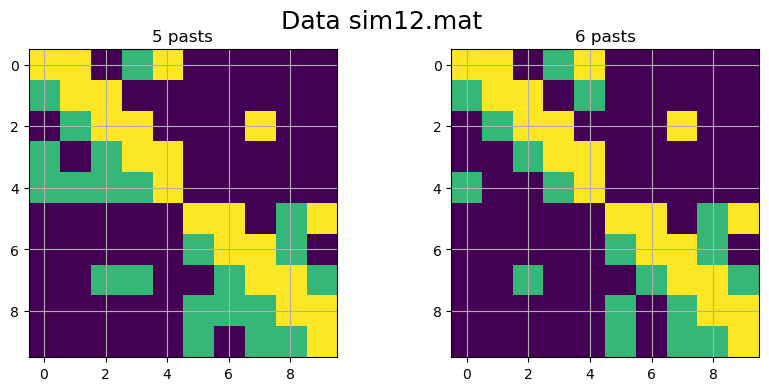

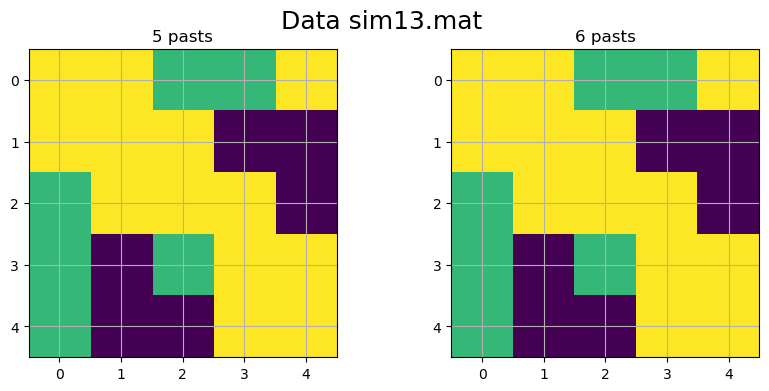

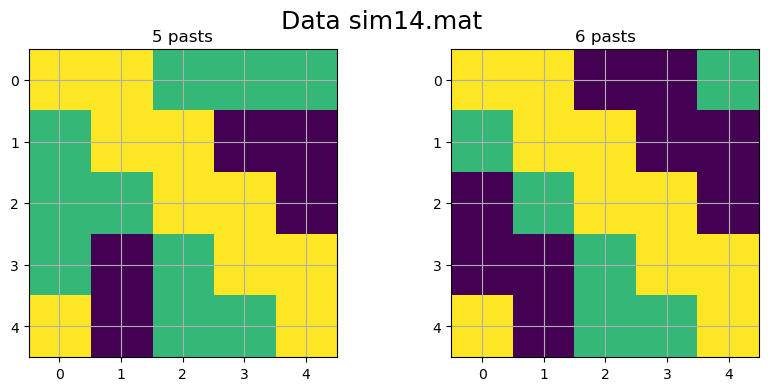

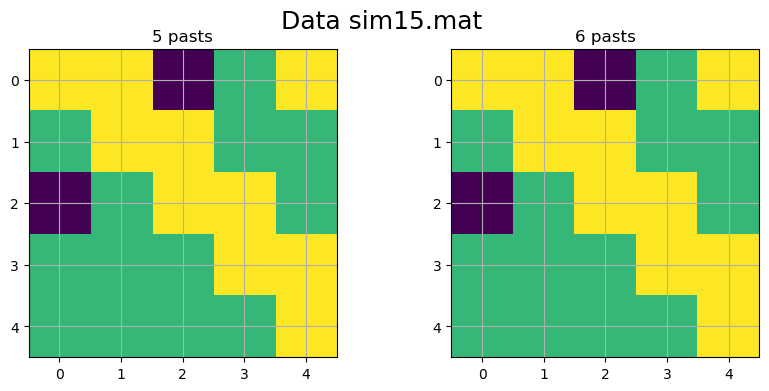

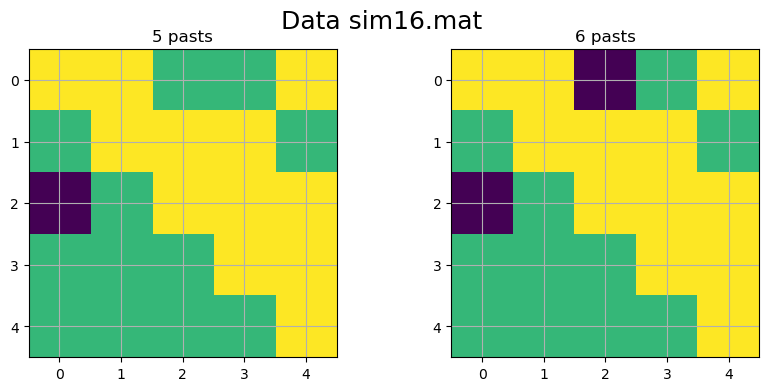

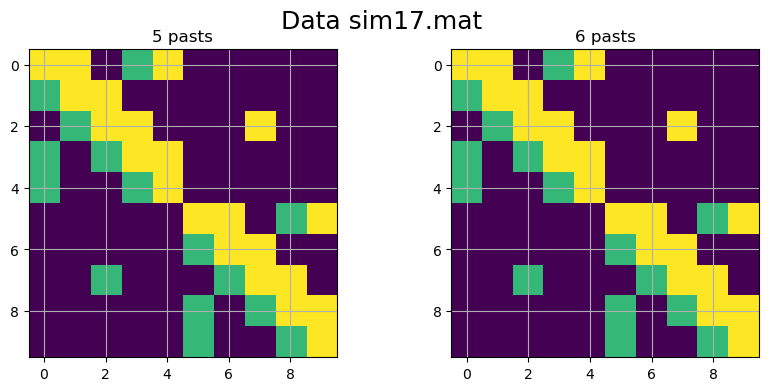

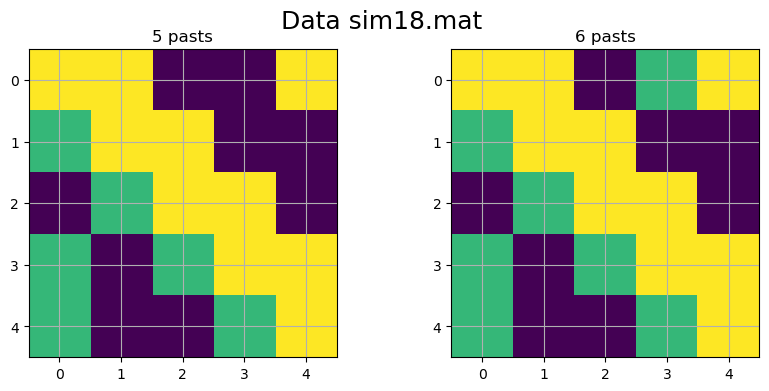

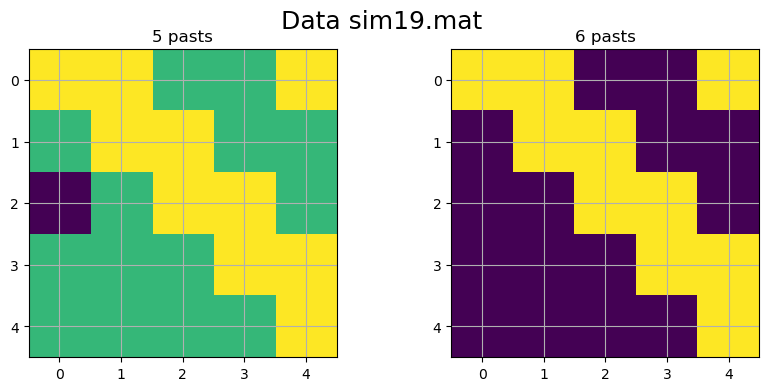

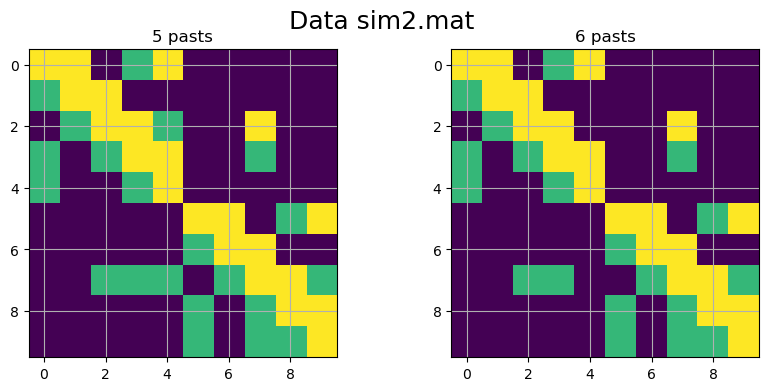

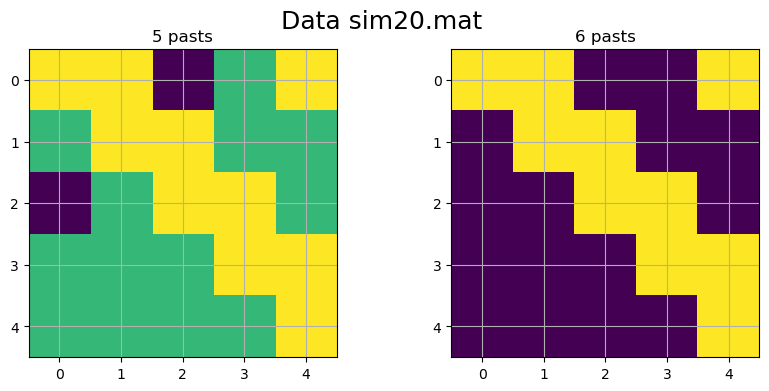

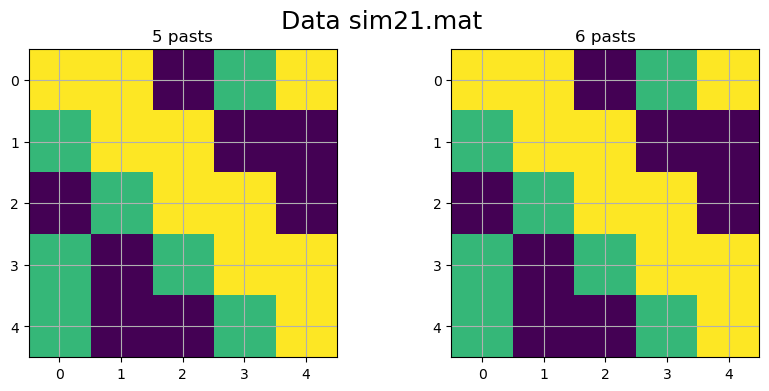

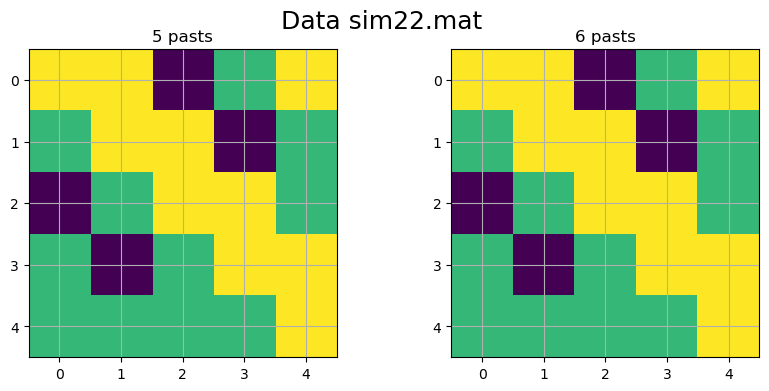

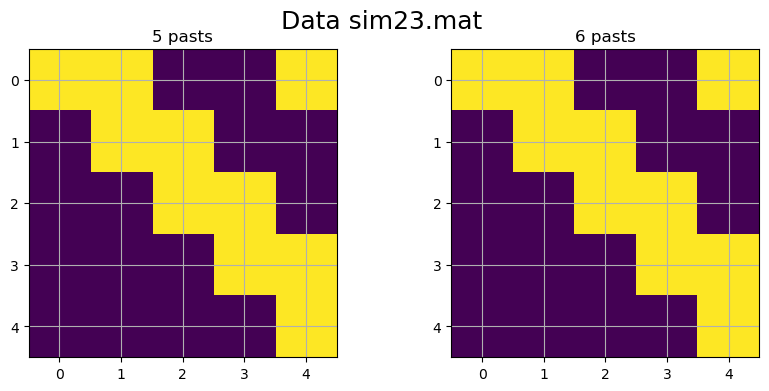

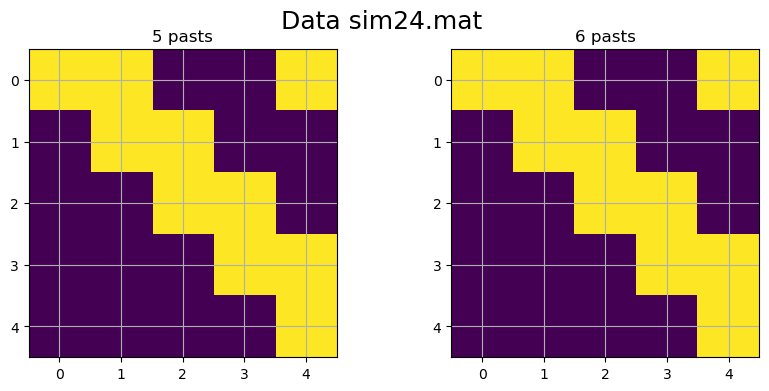

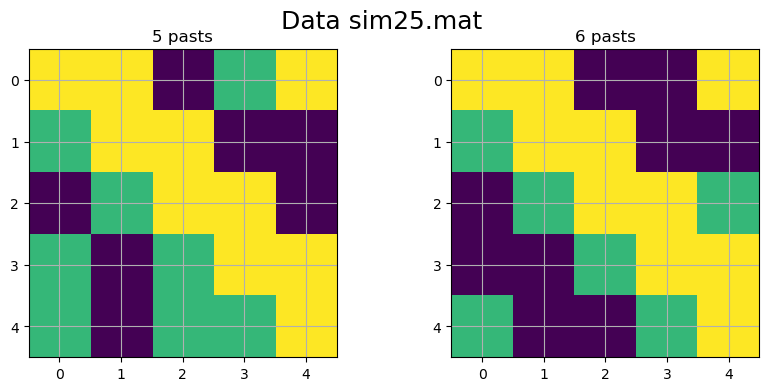

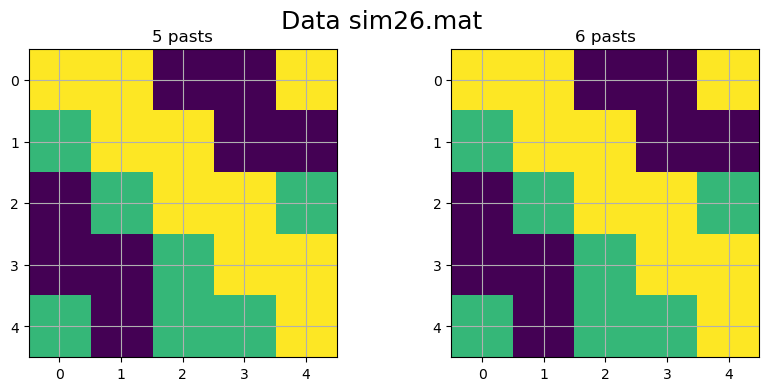

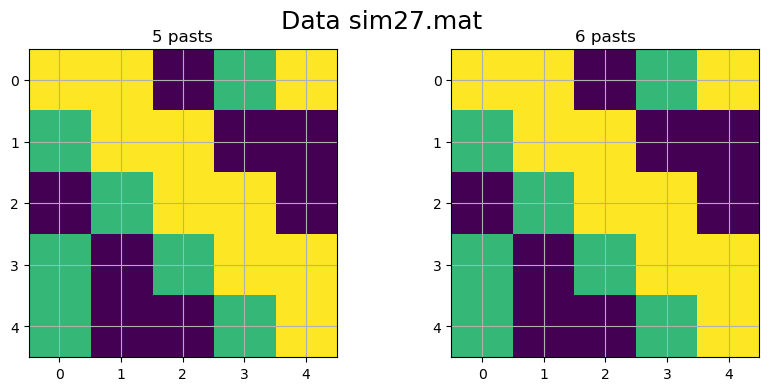

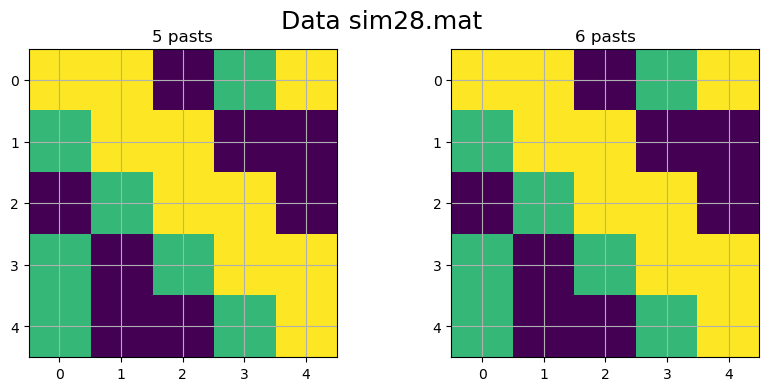

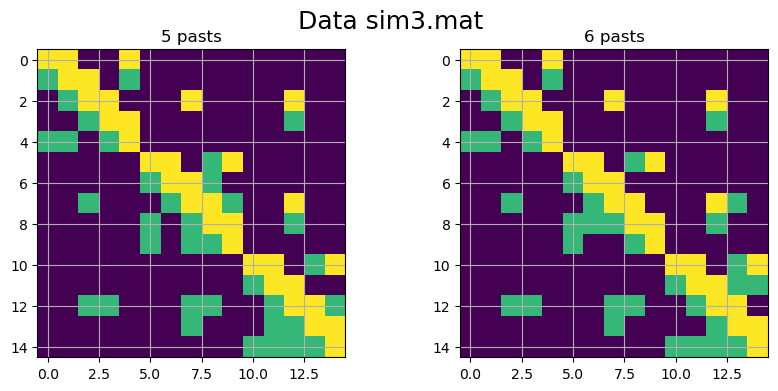

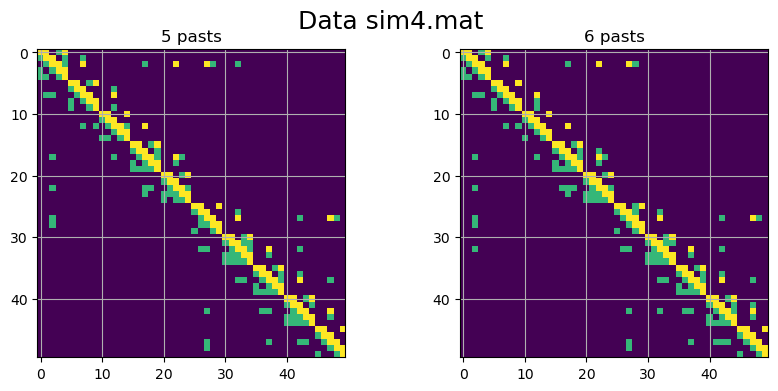

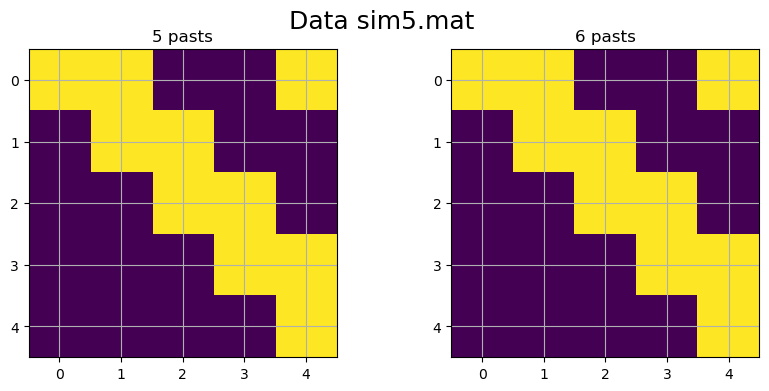

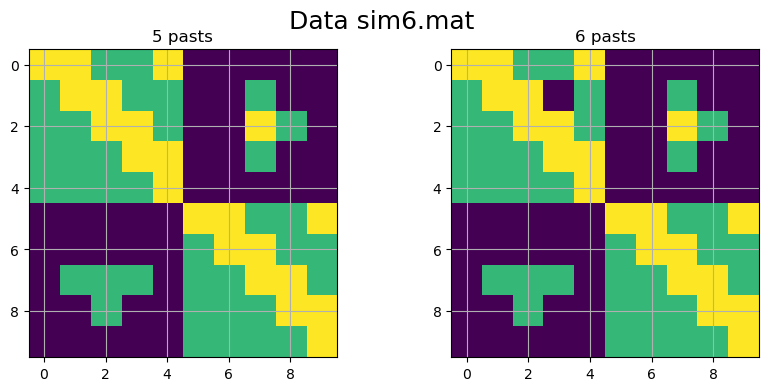

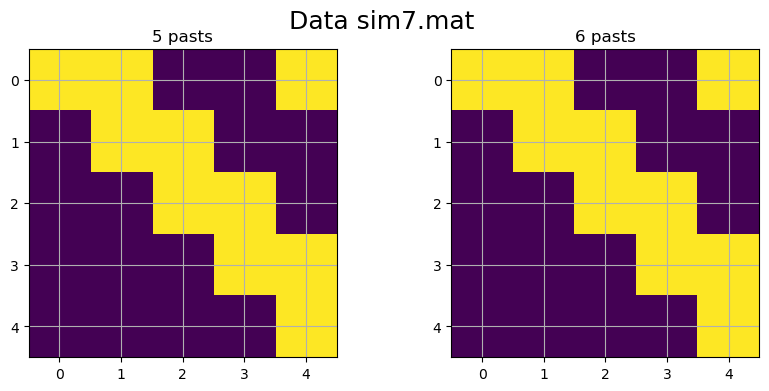

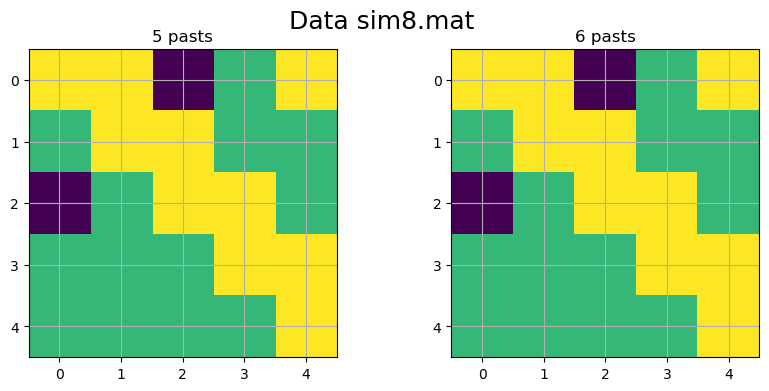

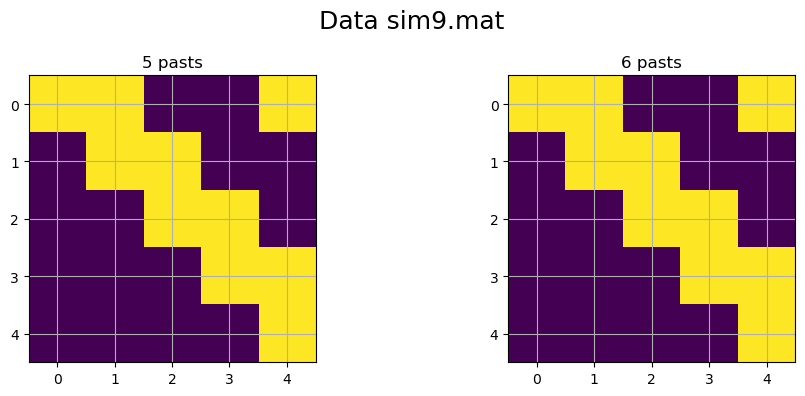

In [9]:
for i in range(28):
  A = make_GT(names[i])
  fig,ax = plt.subplots(1,2,figsize=(10,4))
  for j in range(2):
    ax[j].imshow(mat_func(A.T, INFs[names[i]][j]))
    ax[j].set_title(f'{j+5} pasts')
#     ax[j].set_xticks(np.arange(INFs[i][j].shape[0]))
#     ax[j].set_yticks(np.arange(INFs[i][j].shape[0]))
#     ax[j].set_xticklabels(pro,rotation=90)
#     ax[j].set_yticklabels(pro)
    ax[j].grid()
  plt.suptitle(f'Data {names[i]}', fontsize=18)
  # print('')
  # print('')
plt.tight_layout()

# On timeseries datas

In [10]:
def make_GT(name):
    dat = pd.read_csv(name,header=0)   # load_data(name)
    data = dat.values.T # dat['ts'].T
    n = data.shape[0]
    
    gt_name = 'sim' + names[i][:names[i].find('.')].replace('timeseries', '') + '_gt_processed.csv'
    #start = name.find('.')
    #gt_name =          #name[:start] + '_gt_processed.csv'
    

    df = pd.read_csv(gt_name, header=None)
    gt = df.values
    GT = np.zeros((n,n))
    for r in gt:
        GT[r[0], r[1]] = 1
    return GT.T

def mat_func(A, inf):
    return (40 * np.logical_and(A != 0, inf != 0) +
                30 * np.logical_and(A == 0, inf != 0) +
                20 * np.logical_and(A != 0, inf == 0) +
                10 * np.logical_and(A == 0, inf == 0))

In [11]:
%%time

# load data
#os.chdir(r'./data/fMRI_sims/')
names = [n for n in os.listdir() if n.endswith('.csv') and '_gt_' not in n]
INFs_new = {}
# CONF_MTX = {}
for i in range(len(names)):
    
    # A = make_GT(names[i])
    X_ = pd.read_csv(names[i], header=0)
    X = X_.values.T
    
    print('Data ' + names[i] + ' with len = {}'.format(X.shape[1]))
    print('')
    # Analysis
    infs = []
    # conf_mtx = []
    for a, n in enumerate(N_PASTS):
        
        print(f'{n} pasts')
        gcstar = GcStar(n_perm = 1000, 
                    n_pasts = n, 
                    n_lags = n_lags,
                    temporal = True,
                    method = ' ')
    
        gcstar.fit(X, verbose = 0)
        inf = gcstar.get_connectivity_matrix(alpha=0.01, beta=0.001, simulation=True)   # 
        infs.append(inf)
        #conf = gcstar.compute_confusion_matrix(A)
        #conf_mtx.append(conf)
        
    INFs_new[names[i]] = infs
    #CONF_MTX[names[i]] = conf_mtx
    print('')
    print('')

Data timeseries1.csv with len = 200

2 pasts
3 pasts


Data timeseries10.csv with len = 200

2 pasts
3 pasts


Data timeseries11.csv with len = 200

2 pasts
3 pasts


Data timeseries12.csv with len = 200

2 pasts
3 pasts


Data timeseries13.csv with len = 200

2 pasts
3 pasts


Data timeseries14.csv with len = 200

2 pasts
3 pasts


Data timeseries15.csv with len = 200

2 pasts
3 pasts


Data timeseries16.csv with len = 200

2 pasts
3 pasts


Data timeseries17.csv with len = 200

2 pasts
3 pasts


Data timeseries18.csv with len = 200

2 pasts
3 pasts


Data timeseries19.csv with len = 2400

2 pasts
3 pasts


Data timeseries2.csv with len = 200

2 pasts
3 pasts


Data timeseries20.csv with len = 2400

2 pasts
3 pasts


Data timeseries21.csv with len = 200

2 pasts
3 pasts


Data timeseries22.csv with len = 200

2 pasts
3 pasts


Data timeseries23.csv with len = 200

2 pasts
3 pasts


Data timeseries24.csv with len = 200

2 pasts
3 pasts


Data timeseries25.csv with len = 100

2 pasts
3 

C:\Users\sadiq\AppData\Local\Temp\ipykernel_22232\569369888.py:5: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure()


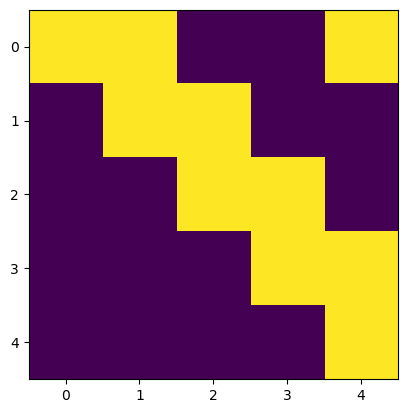

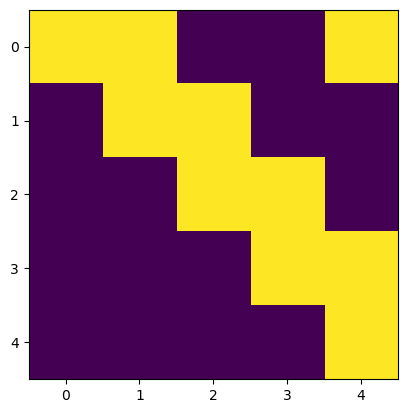

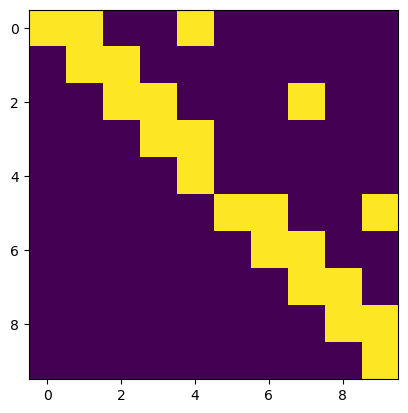

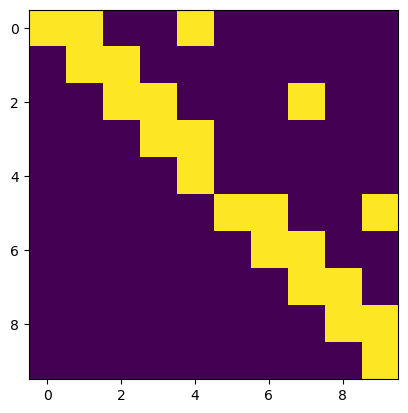

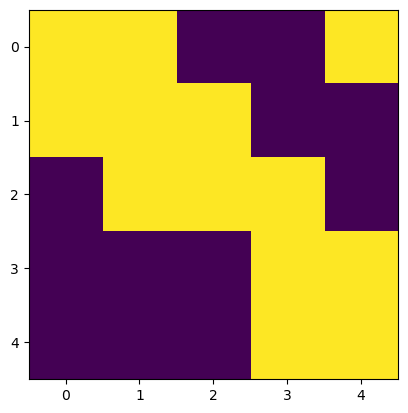

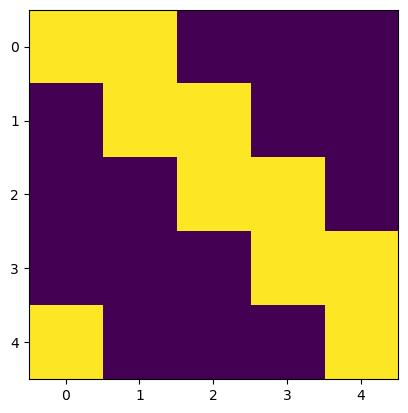

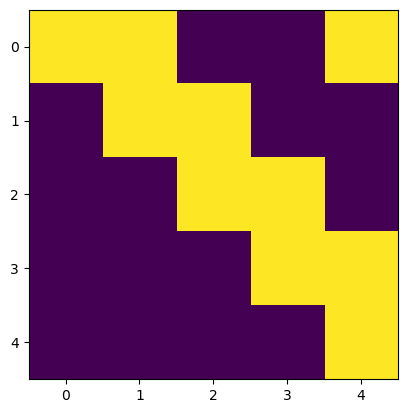

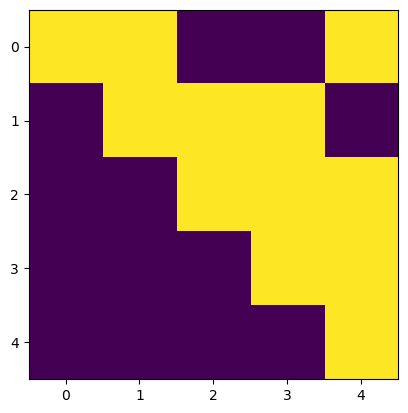

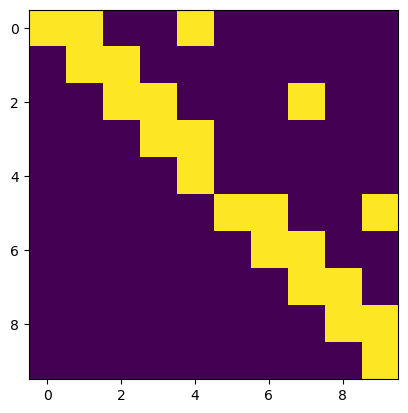

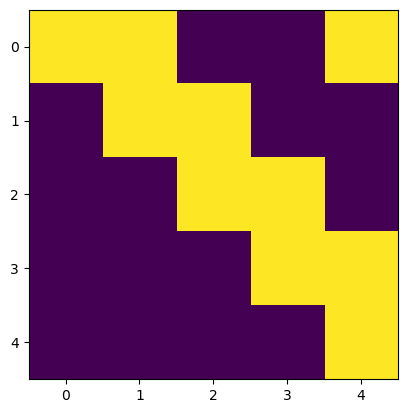

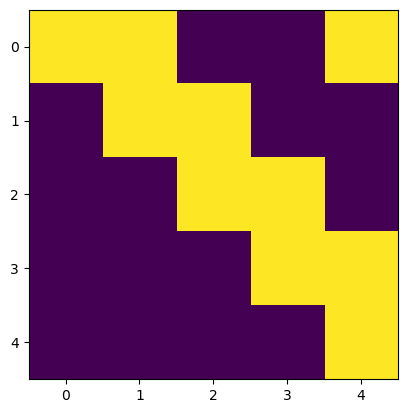

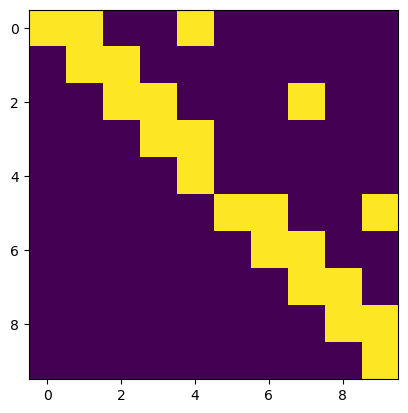

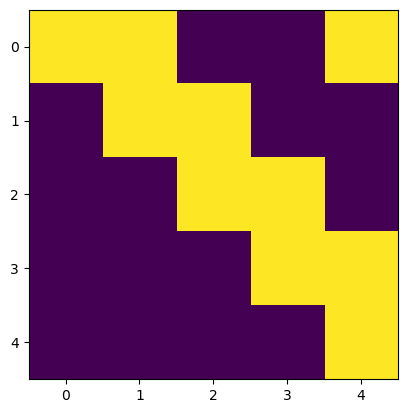

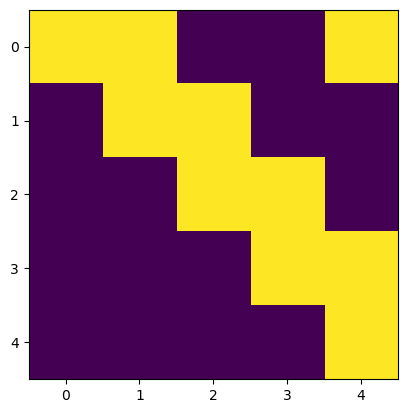

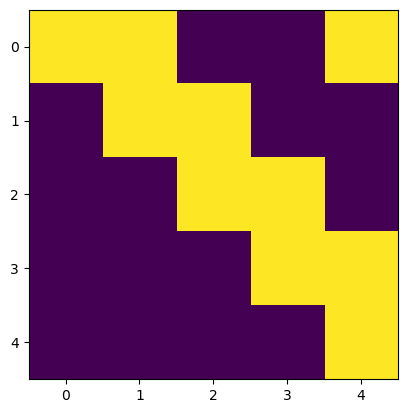

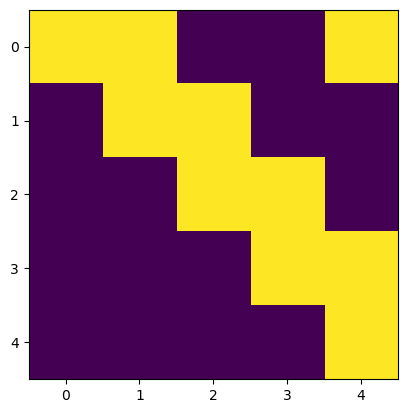

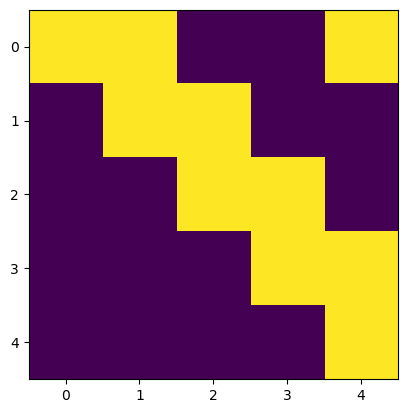

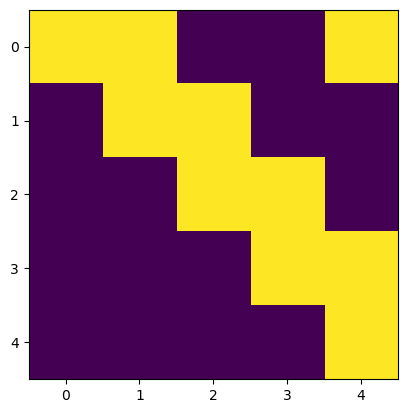

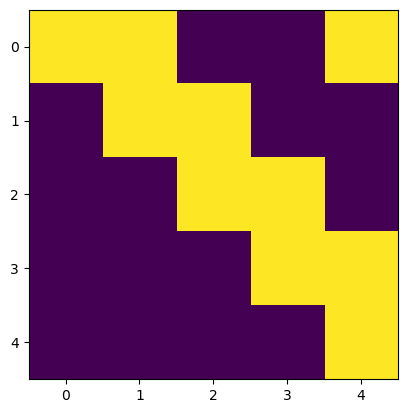

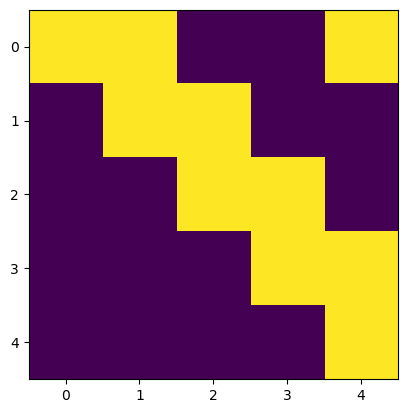

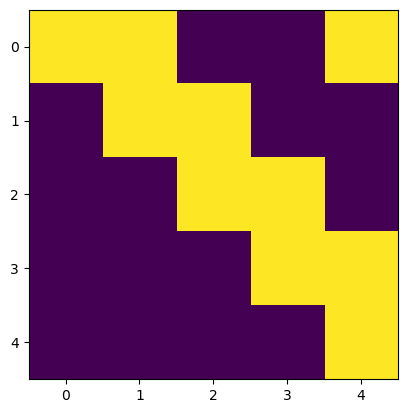

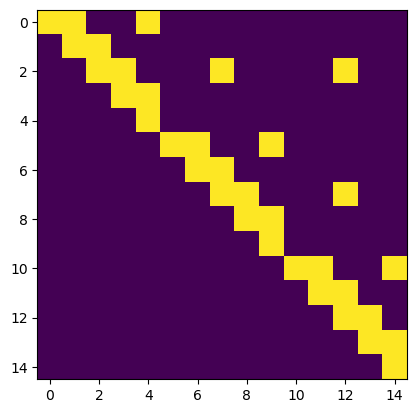

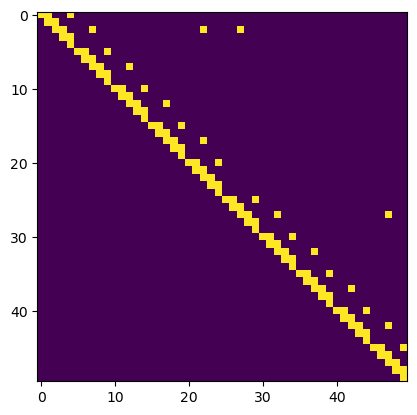

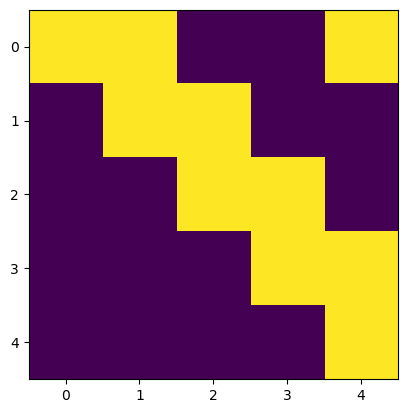

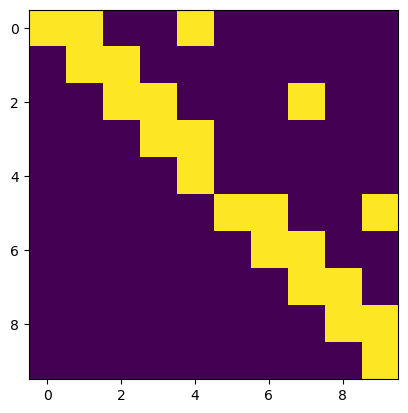

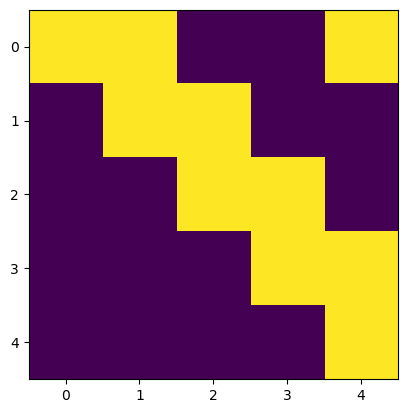

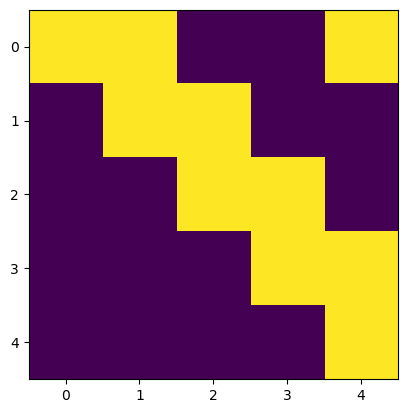

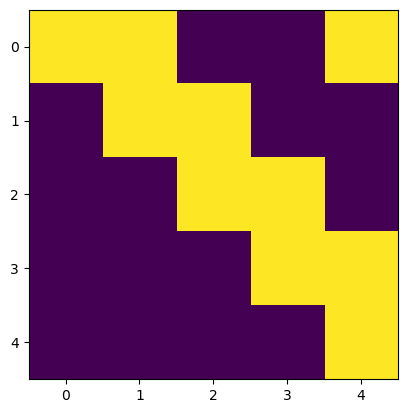

In [12]:
#names = [n for n in os.listdir() if n.endswith('.csv') and 'timeseries' in n]
GTs = {}
for i in range(len(names)):
    GTs[names[i]] = make_GT(names[i])
    plt.figure()
    plt.imshow(make_GT(names[i]))

In [13]:
print(INFs_new.keys())

dict_keys(['timeseries1.csv', 'timeseries10.csv', 'timeseries11.csv', 'timeseries12.csv', 'timeseries13.csv', 'timeseries14.csv', 'timeseries15.csv', 'timeseries16.csv', 'timeseries17.csv', 'timeseries18.csv', 'timeseries19.csv', 'timeseries2.csv', 'timeseries20.csv', 'timeseries21.csv', 'timeseries22.csv', 'timeseries23.csv', 'timeseries24.csv', 'timeseries25.csv', 'timeseries26.csv', 'timeseries27.csv', 'timeseries28.csv', 'timeseries3.csv', 'timeseries4.csv', 'timeseries5.csv', 'timeseries6.csv', 'timeseries7.csv', 'timeseries8.csv', 'timeseries9.csv'])


In [14]:
INFs_new

{'timeseries1.csv': [array([[1., 0., 0., 0., 0.],
         [0., 1., 0., 0., 0.],
         [0., 0., 1., 0., 0.],
         [0., 0., 0., 1., 0.],
         [0., 0., 0., 0., 1.]]),
  array([[1., 0., 0., 0., 0.],
         [0., 1., 0., 0., 0.],
         [0., 0., 1., 0., 0.],
         [0., 0., 0., 1., 0.],
         [0., 0., 0., 0., 1.]])],
 'timeseries10.csv': [array([[1., 0., 0., 0., 0.],
         [0., 1., 0., 0., 0.],
         [0., 0., 1., 0., 0.],
         [0., 0., 0., 1., 0.],
         [0., 0., 0., 0., 1.]]),
  array([[1., 0., 0., 0., 0.],
         [0., 1., 0., 0., 0.],
         [0., 0., 1., 0., 0.],
         [0., 0., 0., 1., 0.],
         [0., 0., 0., 0., 1.]])],
 'timeseries11.csv': [array([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
         [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 1., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
     

C:\Users\sadiq\AppData\Local\Temp\ipykernel_22232\2201291397.py:6: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig,ax = plt.subplots(1,2,figsize=(10,4))


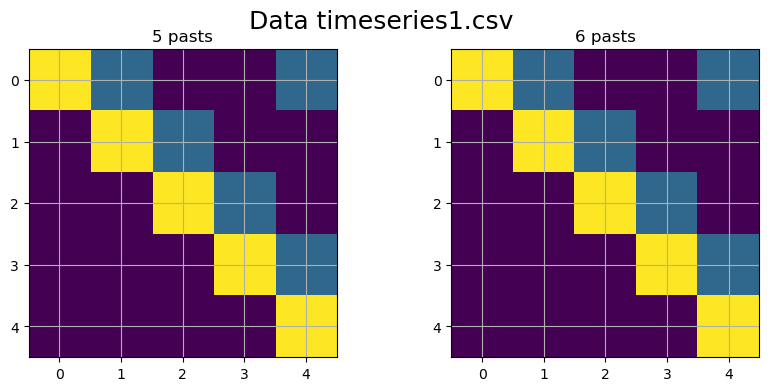

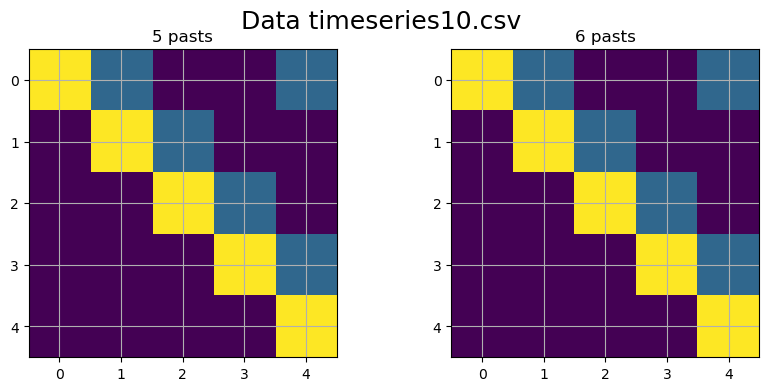

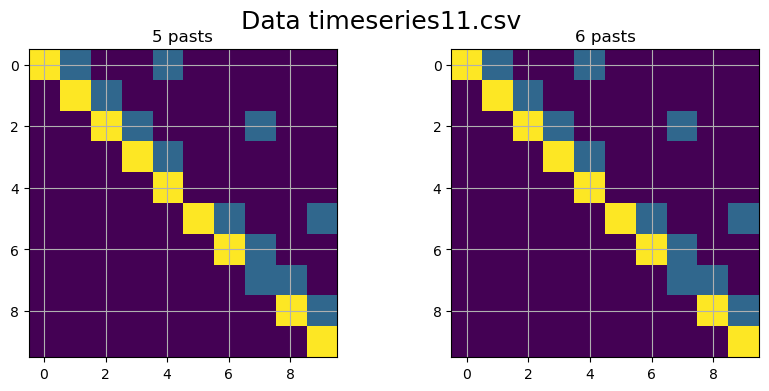

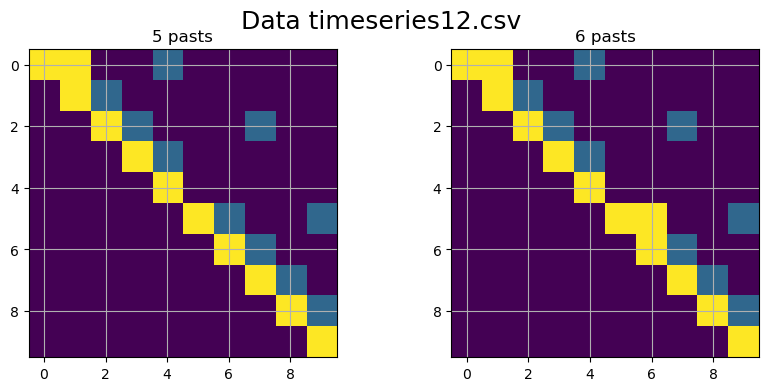

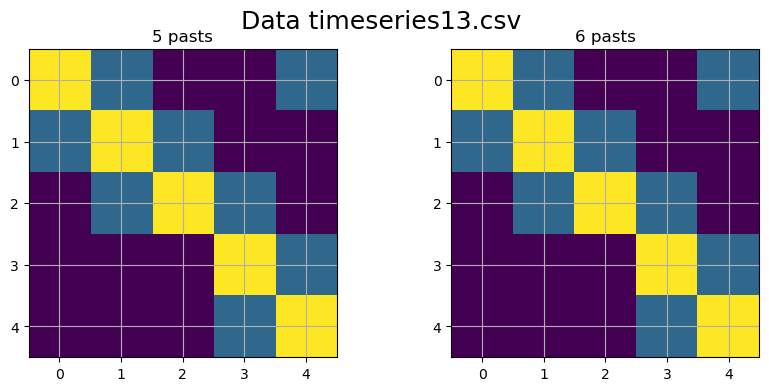

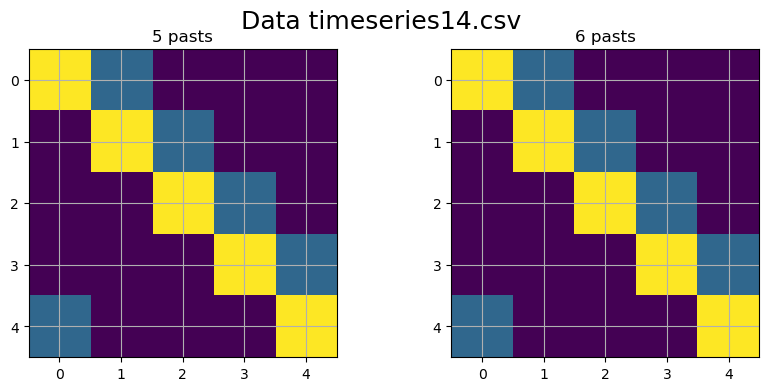

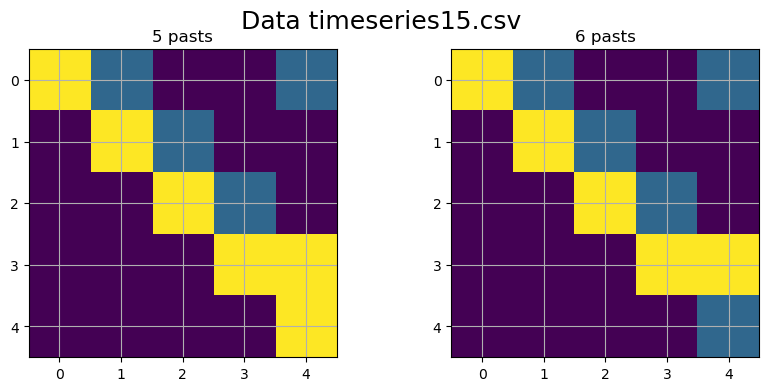

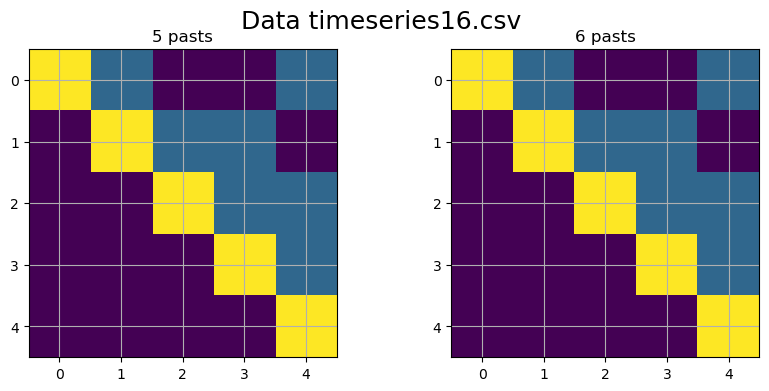

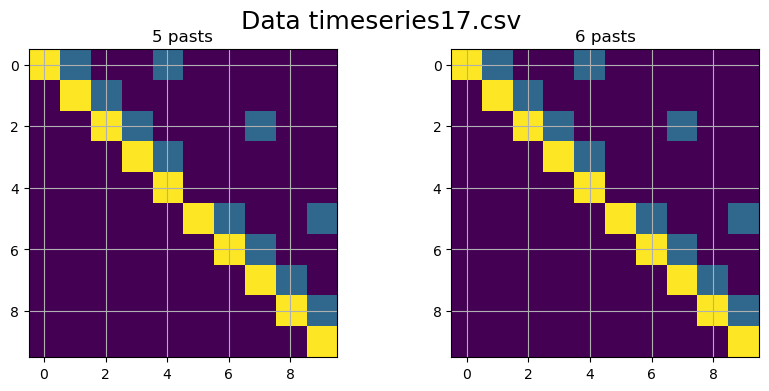

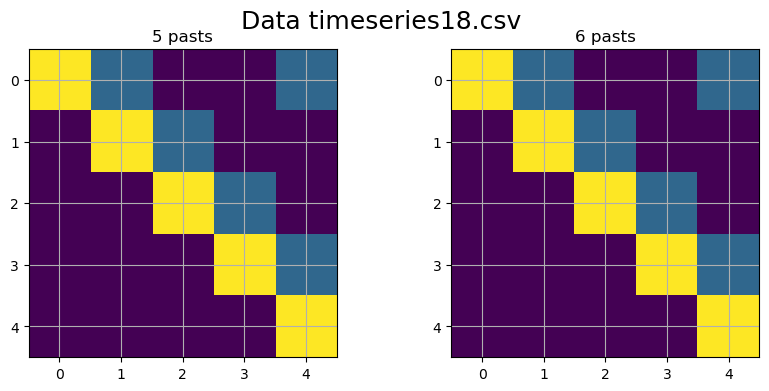

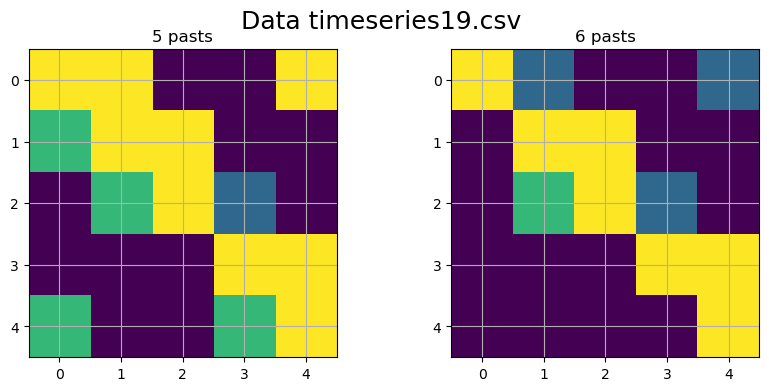

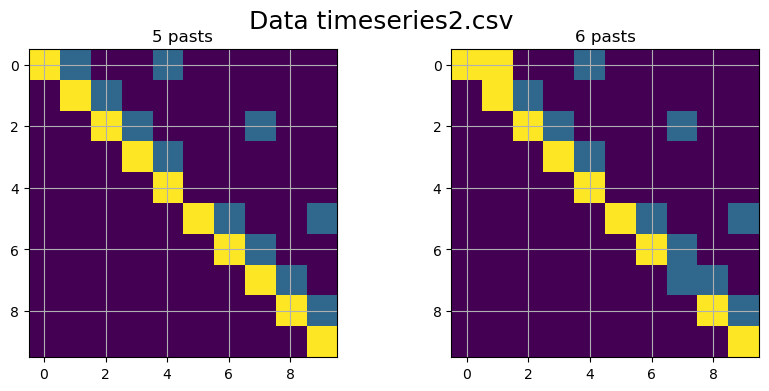

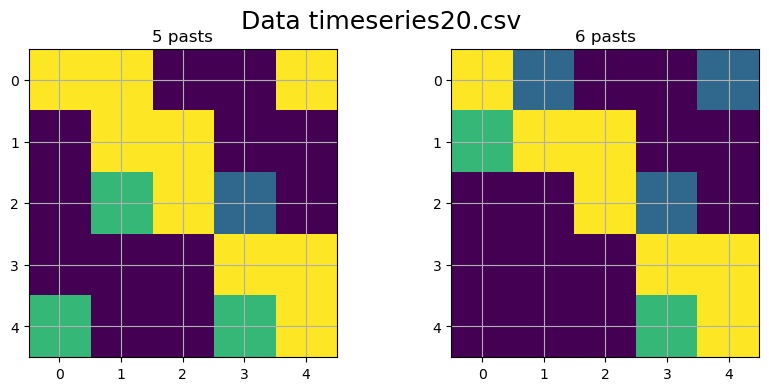

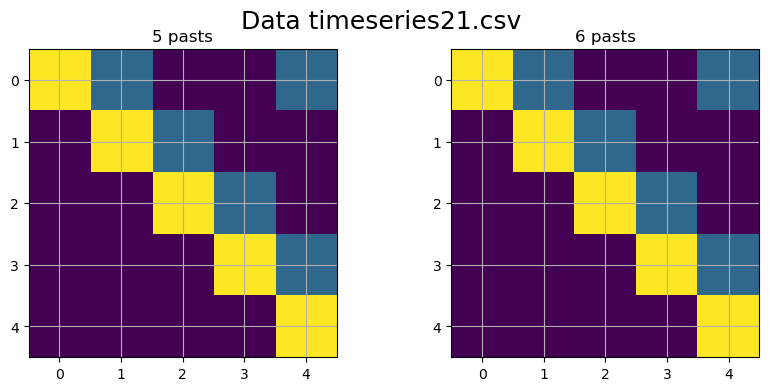

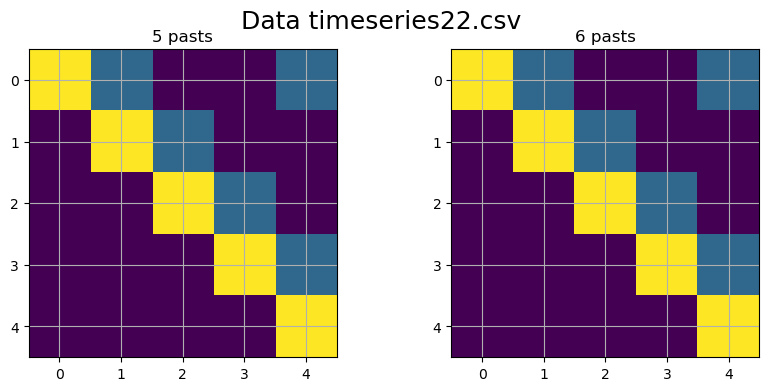

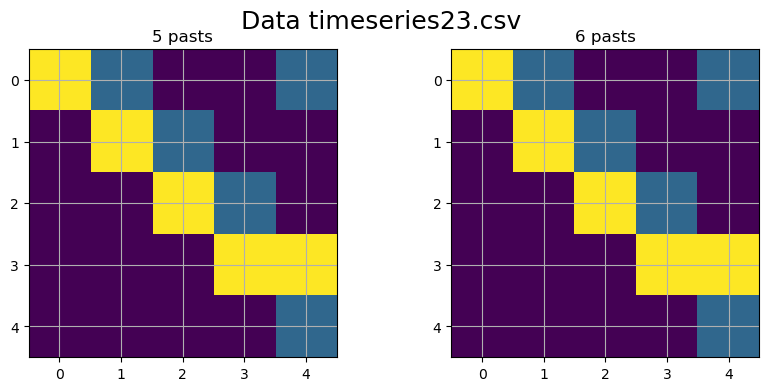

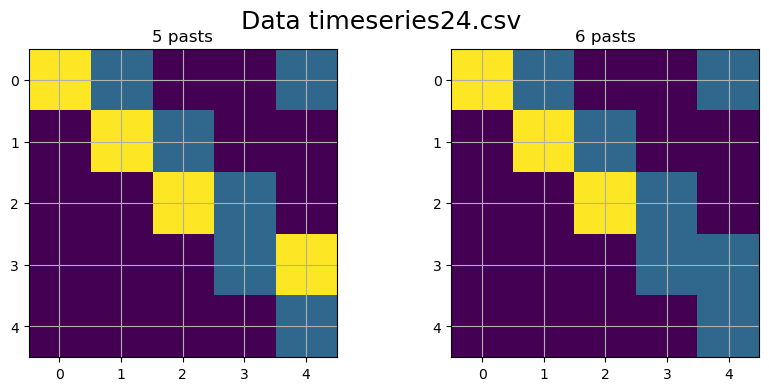

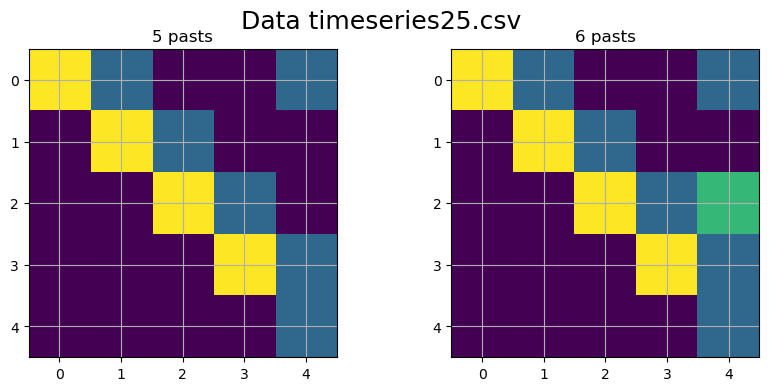

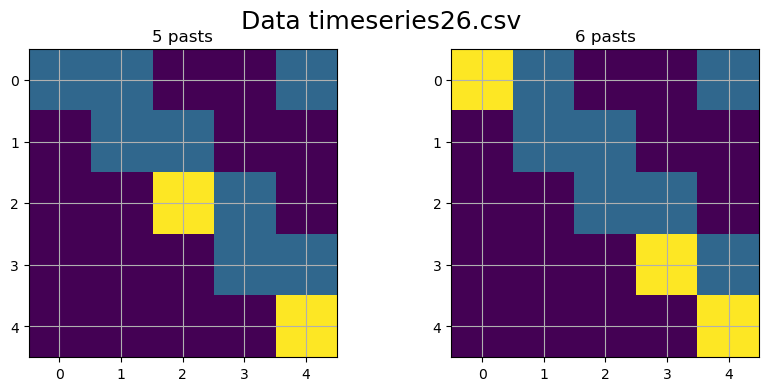

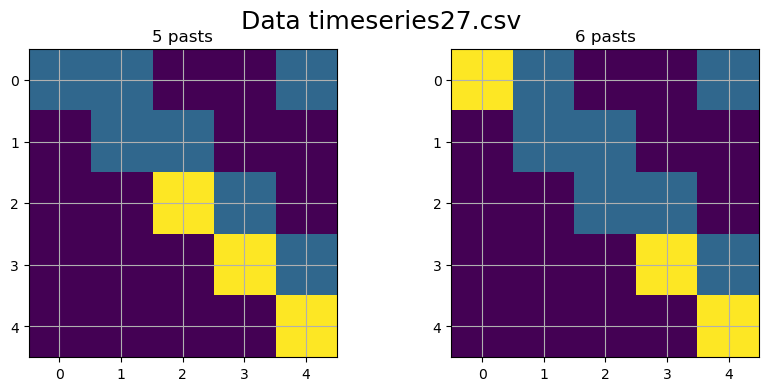

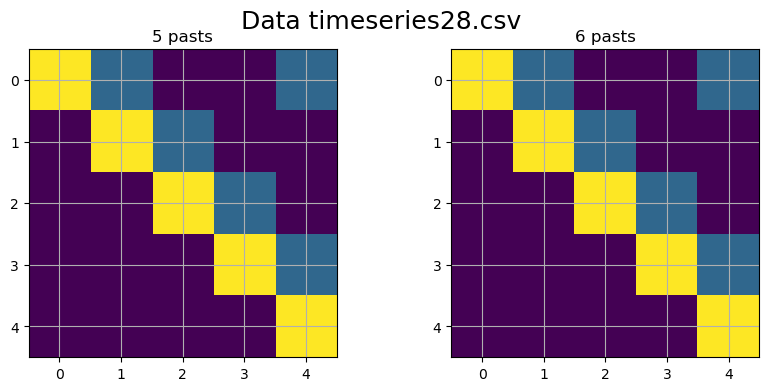

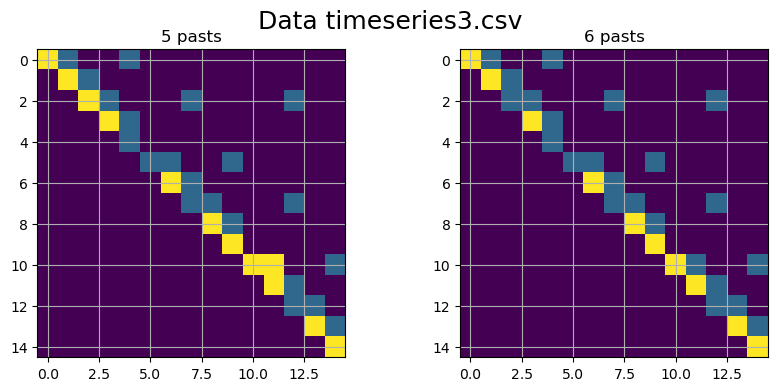

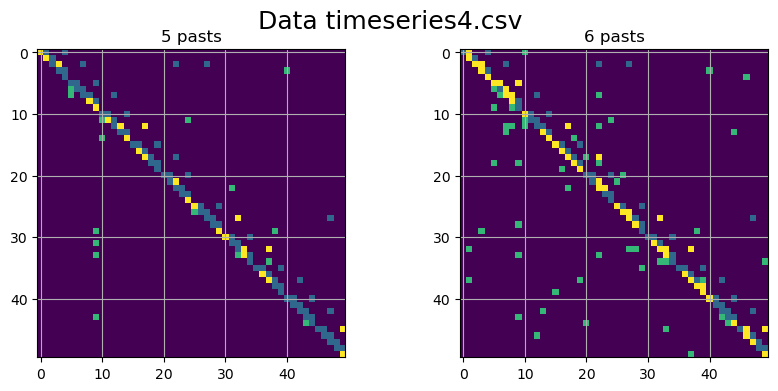

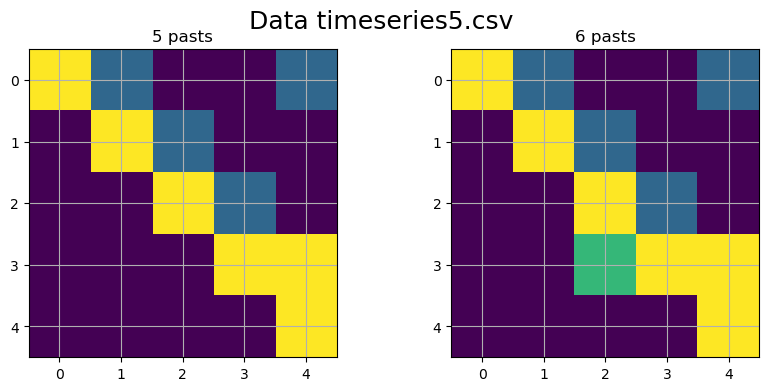

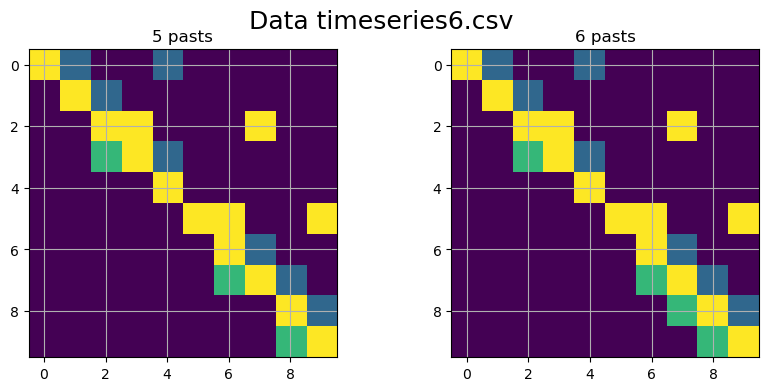

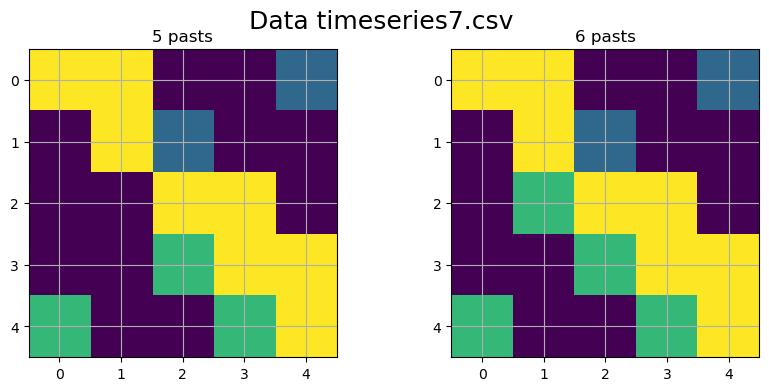

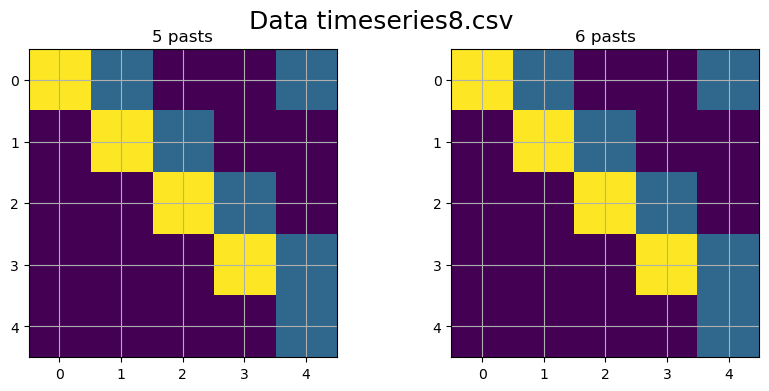

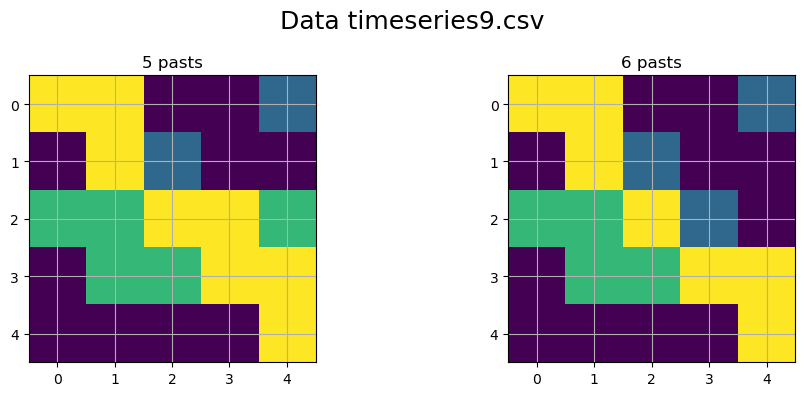

In [15]:
CONFs_new = {}
METs_new = {}
for i, keys in enumerate(INFs_new):  
    gt = GTs[keys]
    confs, mets = [], []
    fig,ax = plt.subplots(1,2,figsize=(10,4))
    for j in range(2):
        c = confusion_matrix(INFs_new[keys][j], gt)
        confs.append(c)
        mets.append(apr_metrics(c))
        
        
        ax[j].imshow(mat_func(gt, INFs_new[keys][j]))
        ax[j].set_title(f'{j+5} pasts')
        ax[j].grid()
    plt.suptitle(f'Data {names[i]}', fontsize=18)
    
    CONFs_new[keys], METs_new[keys] = confs, mets
plt.tight_layout()

In [16]:
METs_new

{'timeseries1.csv': [array([0.8, 1. , 0.5, 0. ]), array([0.8, 1. , 0.5, 0. ])],
 'timeseries10.csv': [array([0.8, 1. , 0.5, 0. ]),
  array([0.8, 1. , 0.5, 0. ])],
 'timeseries11.csv': [array([0.88      , 1.        , 0.42857143, 0.        ]),
  array([0.88      , 1.        , 0.42857143, 0.        ])],
 'timeseries12.csv': [array([0.9       , 1.        , 0.52380952, 0.        ]),
  array([0.91      , 1.        , 0.57142857, 0.        ])],
 'timeseries13.csv': [array([0.68      , 1.        , 0.38461538, 0.        ]),
  array([0.68      , 1.        , 0.38461538, 0.        ])],
 'timeseries14.csv': [array([0.8, 1. , 0.5, 0. ]),
  array([0.8, 1. , 0.5, 0. ])],
 'timeseries15.csv': [array([0.84, 1.  , 0.6 , 0.  ]),
  array([0.8, 1. , 0.5, 0. ])],
 'timeseries16.csv': [array([0.72      , 1.        , 0.41666667, 0.        ]),
  array([0.72      , 1.        , 0.41666667, 0.        ])],
 'timeseries17.csv': [array([0.89      , 1.        , 0.47619048, 0.        ]),
  array([0.89      , 1.        ,

# Selections

In [46]:
N_PASTS, n_lags, n_perm = list(range(3, 10)), 1, 1000

In [47]:
%%time

# load data
#os.chdir(r'./data/fMRI_sims/')
names = ['timeseries19.csv', 'timeseries20.csv', 'timeseries5.csv', 'timeseries6.csv', 'timeseries7.csv', 'timeseries9.csv']
INFs_new = {}
# CONF_MTX = {}
for i in range(len(names)):
    
    # A = make_GT(names[i])
    X_ = pd.read_csv(names[i], header=0)
    X = X_.values.T
    
    print('Data ' + names[i] + ' with len = {}'.format(X.shape[1]))
    print('')
    # Analysis
    infs = []
    # conf_mtx = []
    for a, n in enumerate(N_PASTS):
        
        print(f'{n} pasts')
        gcstar = GcStar(n_perm = 1000, 
                    n_pasts = n, 
                    n_lags = n_lags,
                    temporal = True,
                    method = ' ')
    
        gcstar.fit(X, verbose = 0)
        inf = gcstar.get_connectivity_matrix(alpha=0.001, beta=0, simulation=True)   # 
        infs.append(inf)
        #conf = gcstar.compute_confusion_matrix(A)
        #conf_mtx.append(conf)
        
    INFs_new[names[i]] = infs
    #CONF_MTX[names[i]] = conf_mtx
    print('')
    print('')

Data timeseries19.csv with len = 2400

3 pasts
4 pasts
5 pasts
6 pasts
7 pasts
8 pasts
9 pasts


Data timeseries20.csv with len = 2400

3 pasts
4 pasts
5 pasts
6 pasts
7 pasts
8 pasts
9 pasts


Data timeseries5.csv with len = 1200

3 pasts
4 pasts
5 pasts
6 pasts
7 pasts
8 pasts
9 pasts


Data timeseries6.csv with len = 1200

3 pasts
4 pasts
5 pasts
6 pasts
7 pasts
8 pasts
9 pasts


Data timeseries7.csv with len = 5000

3 pasts
4 pasts
5 pasts
6 pasts
7 pasts
8 pasts
9 pasts


Data timeseries9.csv with len = 5000

3 pasts
4 pasts
5 pasts
6 pasts
7 pasts
8 pasts
9 pasts


CPU times: total: 33min 55s
Wall time: 11min 54s


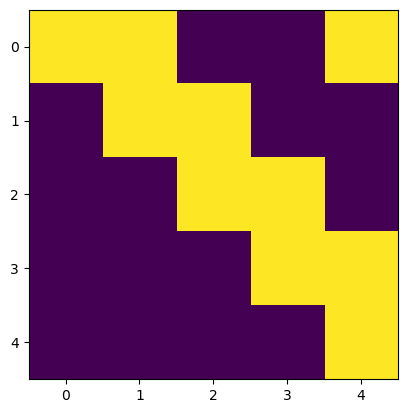

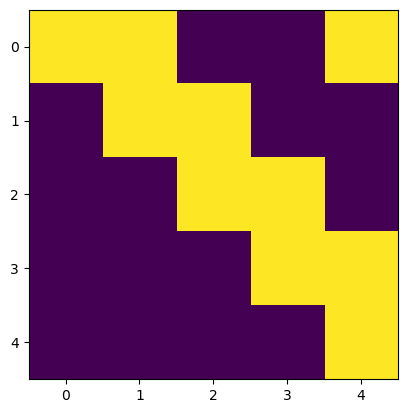

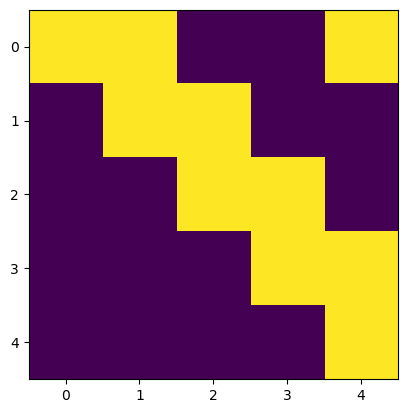

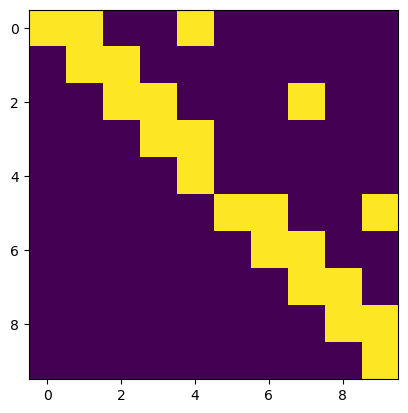

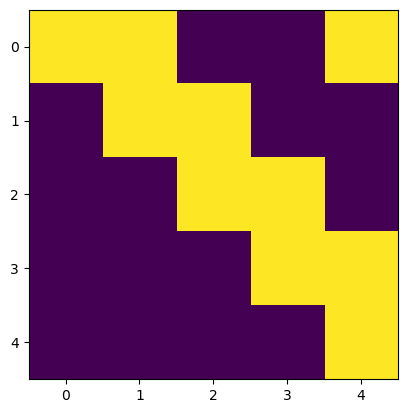

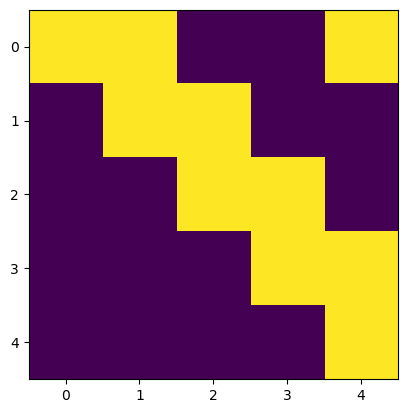

In [48]:
#names = [n for n in os.listdir() if n.endswith('.csv') and 'timeseries' in n]
GTs = {}
for i in range(len(names)):
    GTs[names[i]] = make_GT(names[i])
    plt.figure()
    plt.imshow(make_GT(names[i]))

In [49]:
print(INFs_new.keys())

dict_keys(['timeseries19.csv', 'timeseries20.csv', 'timeseries5.csv', 'timeseries6.csv', 'timeseries7.csv', 'timeseries9.csv'])


In [50]:
INFs_new

{'timeseries19.csv': [array([[1.       , 0.       , 0.       , 0.       , 0.       ],
         [0.       , 1.       , 0.6342958, 0.       , 0.       ],
         [0.       , 0.6342958, 1.       , 0.       , 0.       ],
         [0.       , 0.       , 0.       , 1.       , 0.       ],
         [0.       , 0.       , 0.       , 0.       , 1.       ]]),
  array([[1.        , 0.        , 0.        , 0.        , 0.        ],
         [0.47852046, 1.        , 0.        , 0.        , 0.        ],
         [0.        , 0.        , 1.        , 0.        , 0.        ],
         [0.        , 0.        , 0.        , 1.        , 0.        ],
         [0.        , 0.        , 0.        , 0.        , 1.        ]]),
  array([[1.        , 0.        , 0.        , 0.        , 0.        ],
         [0.47845446, 1.        , 0.63411527, 0.        , 0.        ],
         [0.        , 0.63411527, 1.        , 0.        , 0.        ],
         [0.        , 0.        , 0.        , 1.        , 0.44466951],
       

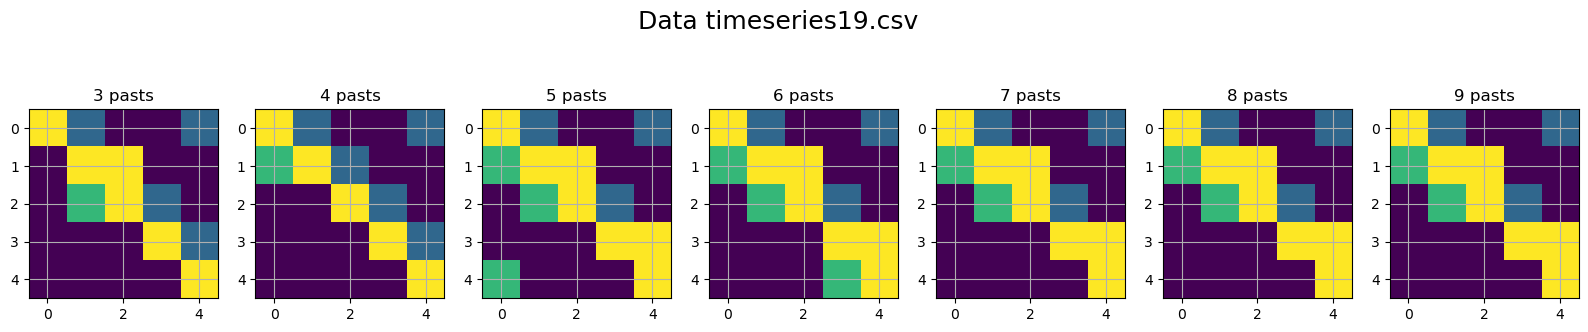

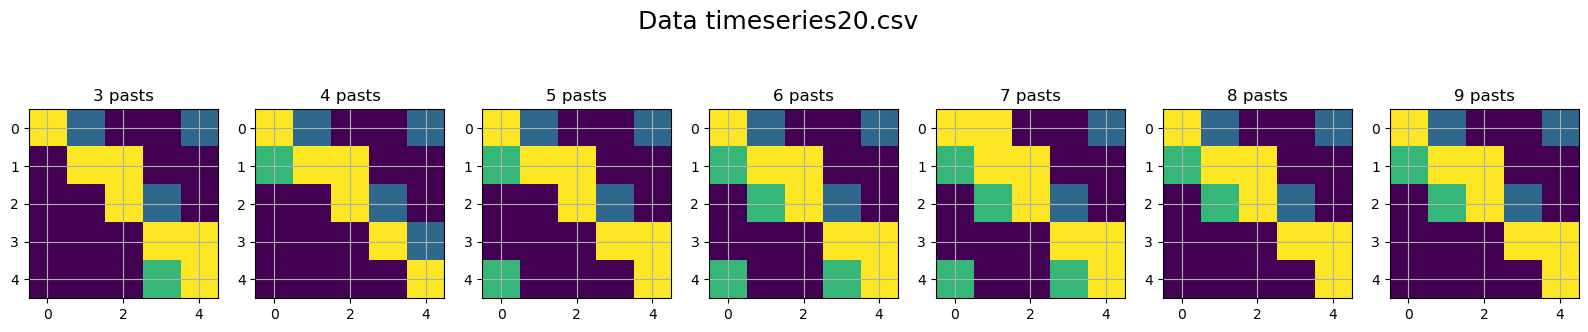

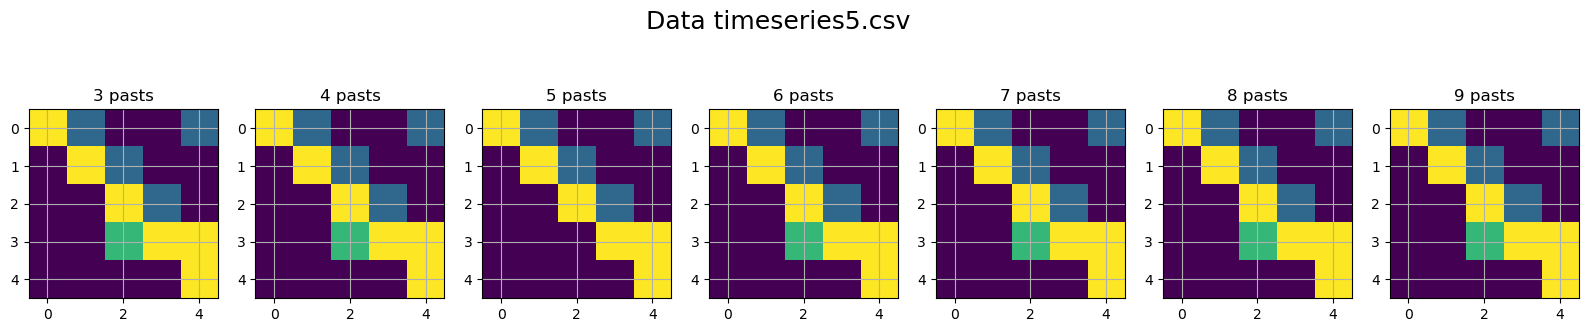

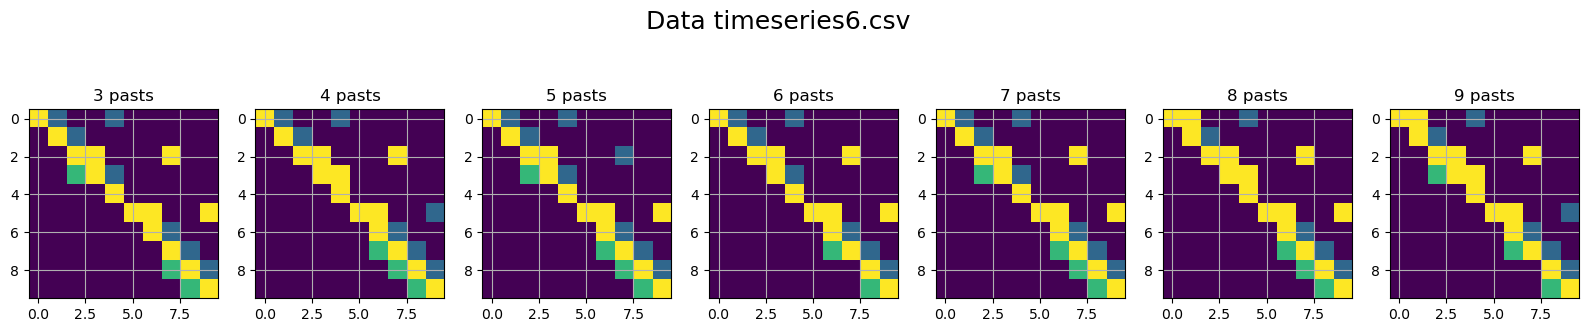

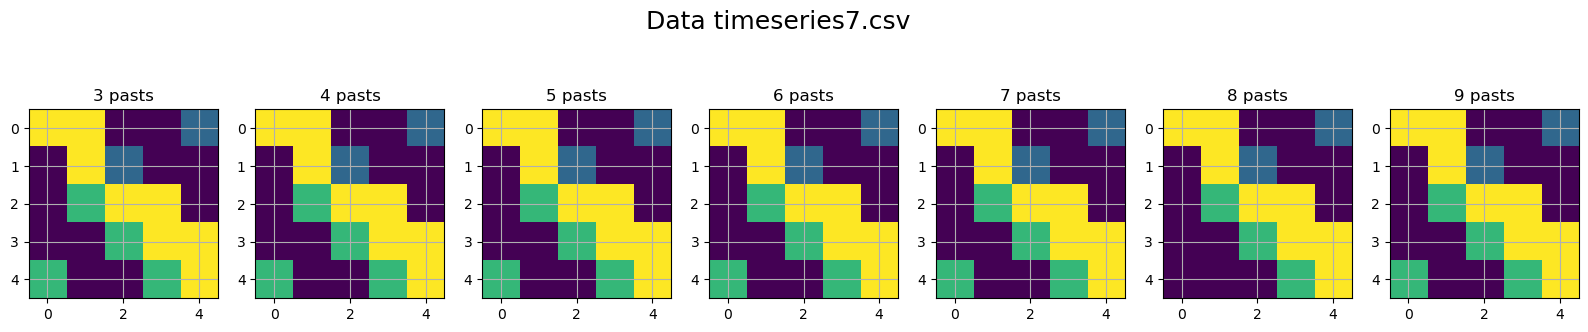

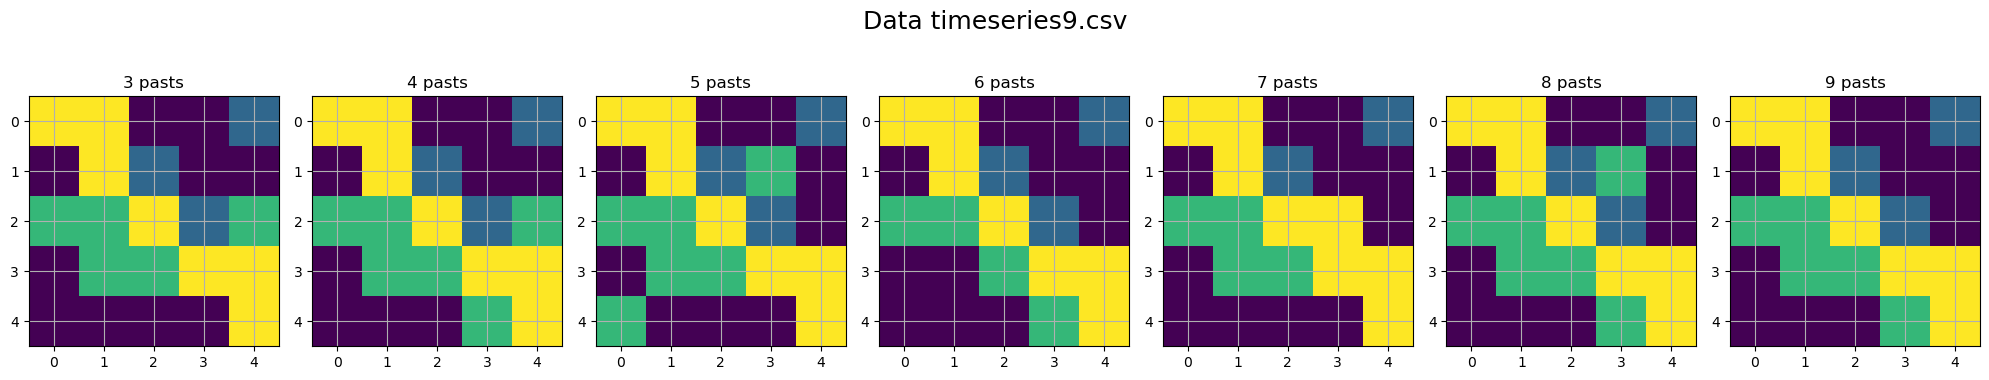

In [53]:
CONFs_new = {}
METs_new = {}
for i, keys in enumerate(INFs_new):  
    gt = GTs[keys]
    confs, mets = [], []
    fig,ax = plt.subplots(1,7,figsize=(20,4))
    for j in range(7):
        c = confusion_matrix(INFs_new[keys][j], gt)
        confs.append(c)
        mets.append(apr_metrics(c))
        
        
        ax[j].imshow(mat_func(gt, INFs_new[keys][j]))
        ax[j].set_title(f'{j+3} pasts')
        ax[j].grid()
    plt.suptitle(f'Data {names[i]}', fontsize=18)
    
    CONFs_new[keys], METs_new[keys] = confs, mets
plt.tight_layout()

In [54]:
METs_new

{'timeseries19.csv': [array([0.8       , 0.85714286, 0.6       , 0.06666667]),
  array([0.76      , 0.83333333, 0.5       , 0.06666667]),
  array([0.76, 0.7 , 0.7 , 0.2 ]),
  array([0.76, 0.7 , 0.7 , 0.2 ]),
  array([0.8       , 0.77777778, 0.7       , 0.13333333]),
  array([0.8       , 0.77777778, 0.7       , 0.13333333]),
  array([0.8       , 0.77777778, 0.7       , 0.13333333])],
 'timeseries20.csv': [array([0.84      , 0.875     , 0.7       , 0.06666667]),
  array([0.8       , 0.85714286, 0.6       , 0.06666667]),
  array([0.8       , 0.77777778, 0.7       , 0.13333333]),
  array([0.72      , 0.63636364, 0.7       , 0.26666667]),
  array([0.76      , 0.66666667, 0.8       , 0.26666667]),
  array([0.8       , 0.77777778, 0.7       , 0.13333333]),
  array([0.8       , 0.77777778, 0.7       , 0.13333333])],
 'timeseries5.csv': [array([0.8       , 0.85714286, 0.6       , 0.06666667]),
  array([0.8       , 0.85714286, 0.6       , 0.06666667]),
  array([0.84, 1.  , 0.6 , 0.  ]),
  array(

In [55]:
for key in METs_new:
    print(f'mean = {np.mean(METs_new[key], axis=0)}')
    print(f'std = {np.std(METs_new[key], axis=0)}')  
    print('')

mean = [0.78285714 0.77482993 0.65714286 0.13333333]
std = [0.01979487 0.05532136 0.07284314 0.05039526]

mean = [0.78857143 0.7669295  0.7        0.15238095]
std = [0.03522522 0.08217648 0.05345225 0.07737179]

mean = [0.80571429 0.87755102 0.6        0.05714286]
std = [0.01399708 0.04998959 0.         0.02332847]

mean = [0.90142857 0.8199973  0.68027211 0.039783  ]
std = [0.012454   0.0349622  0.04193479 0.00808705]

mean = [0.76571429 0.67532468 0.8        0.25714286]
std = [1.39970842e-02 2.12077034e-02 1.11022302e-16 2.33284737e-02]

mean = [0.68       0.58358308 0.71428571 0.34285714]
std = [0.0427618  0.04750437 0.03499271 0.05553288]

